In [1]:
from api_stable.mammography import MammographyDicom
from encoder_service import MammographyEncoder

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'api_stable').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [3]:
#DICOM_PATH = Path('/workspace/Data/NL-breast/abnormal/p_4333/left-c/CC/IM-0126-0002-0001.dcm')
#DICOM_PATH = Path('/workspace/Data/CMMD/cmmd/D1-0001/79377/70244/608a073d-14ef-455b-be5d-f73f553b97f0.dcm')
#DICOM_PATH = Path('/workspace/Data/Mammo-MX/B1/000077_R_MLO_B1_D2')
#DICOM_PATH = Path('/workspace/Data/Mammo-MX/B6/000457_L_MLO_B6_D3')
DICOM_PATH = Path('/workspace/Data/Mammo-MX/B6/001922_R_MLO_B6_D2')

if not DICOM_PATH.exists():
    raise FileNotFoundError(f'Actualiza DICOM_PATH: {DICOM_PATH}')

mammo = MammographyDicom.from_dicom(DICOM_PATH)
# mammo.initialize_image()


img = mammo.image.copy()

In [4]:
print(mammo.metadata)

patient=PatientInfo(patient_id='', age=52, sex='') vendor=VendorInfo(manufacturer='HOLOGIC, Inc.', model_name='Selenia Dimensions') acquisition=AcquisitionInfo(kvp=32.0, exposure=86.0, exposure_time=767.0, tube_current=100.0, compression_force=87.18472) breast=BreastInfo(laterality='R', view='MLO', breast_implant_present=False) image=ImageInfo(rows=4096, columns=3328, bits_stored=12, pixel_spacing=(0.065238, 0.065238), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=['2047'], window_width=['4096'], window_center_width_explanation=[None], voi_lut_function=None)


In [5]:
encoder = MammographyEncoder.encode(mammo)

In [6]:
print(encoder)
import json
print(json.loads(encoder['metadata'])['rows'])

{'data_path': '/tmp/1.2.826.0.1.3680043.8.498.77496701249481011932536461670014204038.nii.gz', 'metadata': '{"patient_id": "", "age": 52, "sex": "", "manufacturer": "HOLOGIC, Inc.", "model_name": "Selenia Dimensions", "kvp": 32.0, "exposure": 86.0, "exposure_time": 767.0, "tube_current": 100.0, "compression_force": 87.18472, "laterality": "R", "view": "MLO", "breast_implant_present": false, "rows": 4096, "columns": 3328, "bits_stored": 12, "pixel_spacing": [0.065238, 0.065238], "photometric_interpretation": "MONOCHROME2", "presentation_lut_shape": "IDENTITY", "window_center": [2047.0], "window_width": [4096.0], "window_center_width_explanation": [null], "voi_lut_function": null}'}
4096


In [7]:
from aip_platform import  AIPlatform

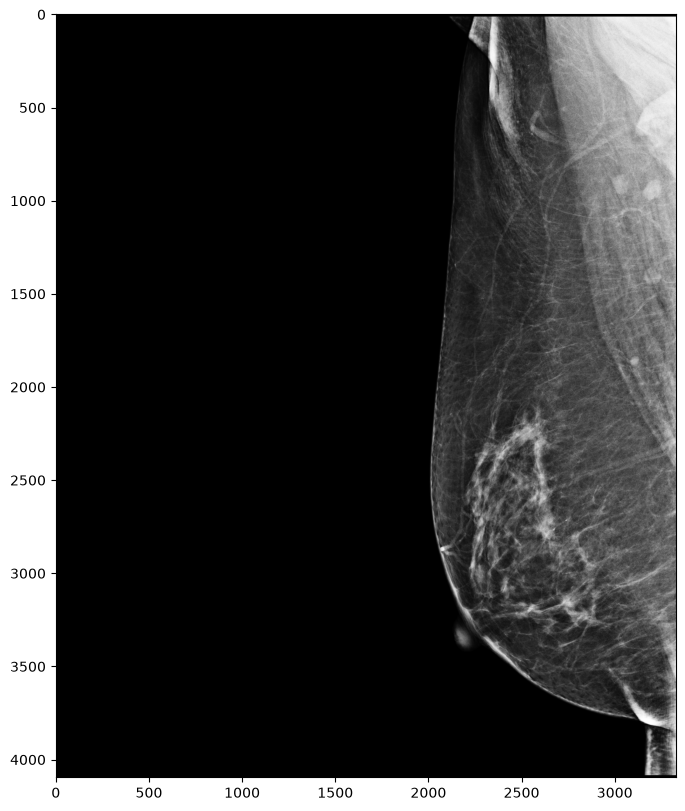

4089.0


In [8]:
import nibabel as nib
import matplotlib.pyplot as plt
en_path = encoder['data_path']
nii_file = nib.load(en_path)
image_array = nii_file.get_fdata()

plt.figure(figsize=(8,15))
plt.imshow(image_array,cmap='gray')
plt.show()

print(image_array.max())

In [9]:
from plugin_manager import PluginManager
manager = PluginManager()
manager.discover()

In [10]:
manager.get_catalog()

{'resnet-classification': <plugin_manager.Plugin at 0x763c74f28290>,
 'yolox': <plugin_manager.Plugin at 0x763c74f33950>,
 'unet-segmentation': <plugin_manager.Plugin at 0x763c3d9d9220>,
 'GMIC': <plugin_manager.Plugin at 0x763c3d7797c0>}

In [11]:
service = AIPlatform()

In [12]:
print(service)

In [13]:
service = AIPlatform()
response_yolo = service.predict('yolox',mammo)
print(response_yolo)

yolox
{'status': 'ok', 'name': 'yolox', 'version': '0.1.0', 'model_loaded': True, 'device': 'cuda'}
{'algorithm': 'yolox', 'version': '0.1.0', 'task': 'breast-detection', 'results': {'num_detections': '1', 'scores': [0.982718288898468], 'boxes': [[1957.824462890625, 896.9732666015625, 3331.20556640625, 3837.198974609375]]}}


In [14]:
from visualization.visualization import image_with_bboxes

In [15]:
from encoder_service import ResultsDecoder
decoder = ResultsDecoder()
print(response_yolo['results']['num_detections'])
print(response_yolo['results']['boxes'])
#print(decoder.decode(response_yolo))

1
[[1957.824462890625, 896.9732666015625, 3331.20556640625, 3837.198974609375]]


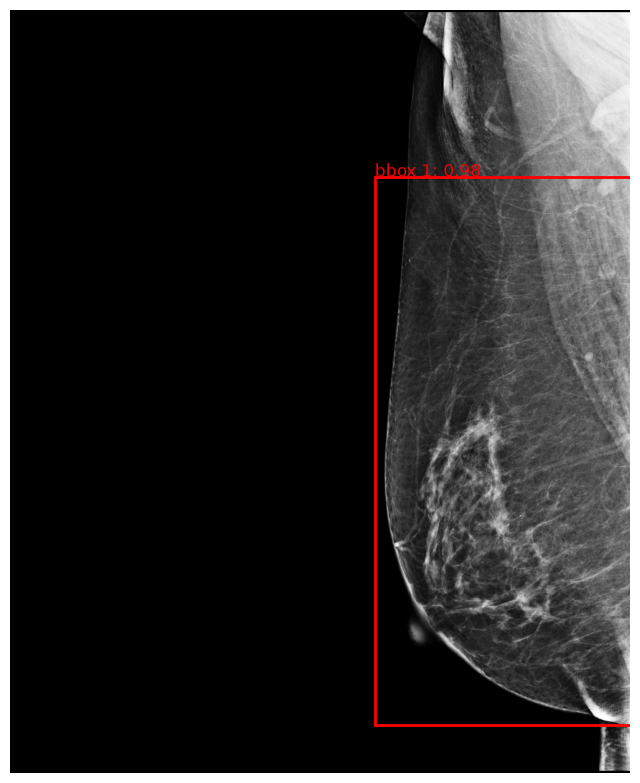

In [16]:
image_with_bboxes(mammo.image.to_numpy(), response_yolo['results'])

In [17]:
service = AIPlatform()
response_gmic = service.predict('GMIC',mammo)
print(response_gmic)

GMIC
{'status': 'ok', 'model_loaded': True, 'device': 'cuda'}
{'algorithm': 'GMIC', 'version': '0.1', 'task': 'classification', 'results': {'score': '0.07402266', 'saliency_map': '/tmp/65d38dae-b512-4253-b47e-f2f5e393bd80.nii.gz'}}


In [18]:
from encoder_service import ResultsDecoder

decoder = ResultsDecoder()
print(response_gmic['results'].items())

info, heatmap = decoder.decode(response_gmic)

dict_items([('score', '0.07402266'), ('saliency_map', '/tmp/65d38dae-b512-4253-b47e-f2f5e393bd80.nii.gz')])


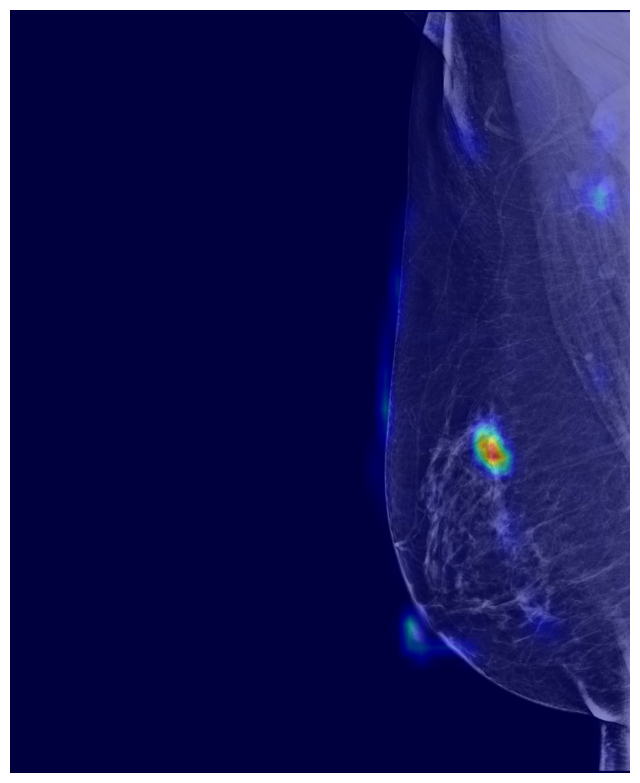

In [19]:
from visualization.visualization import overlay

overlay(mammo.image.to_numpy(), heatmap)

In [20]:
response = service.predict('unet-segmentation', mammo)
print(response)

unet-segmentation
{'status': 'ok', 'model_loaded': True, 'device': 'cuda'}
{'algorithm': 'unet-segmentation', 'version': '0.1', 'task': 'segmentation', 'results': {'segmentation_mask': '/tmp/ba6bdd90-0383-4e4e-9083-1f2f7077c302.nii.gz'}}


In [21]:
from encoder_service import ResultsDecoder

In [22]:
decoder = ResultsDecoder()
print(response['results'].items())

dict_items([('segmentation_mask', '/tmp/ba6bdd90-0383-4e4e-9083-1f2f7077c302.nii.gz')])


In [23]:
info, mask = decoder.decode(response)

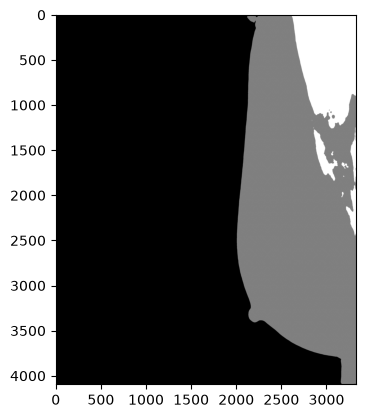

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# plt.imshow(mammo.image.to_numpy(), cmap='gray')
plt.imshow(mask, cmap='gray')
plt.show()

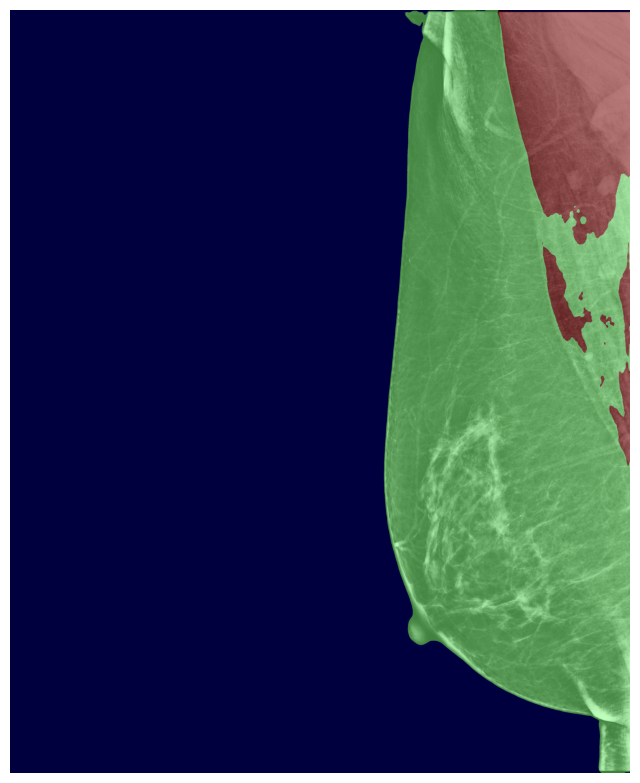

In [25]:
from visualization.visualization import overlay

overlay(mammo.image.to_numpy(), mask)

In [26]:
print(response_yolo)
print(response_gmic)
print(response)


{'algorithm': 'yolox', 'version': '0.1.0', 'task': 'breast-detection', 'results': {'num_detections': '1', 'scores': [0.982718288898468], 'boxes': [[1957.824462890625, 896.9732666015625, 3331.20556640625, 3837.198974609375]]}}
{'algorithm': 'GMIC', 'version': '0.1', 'task': 'classification', 'results': {'score': '0.07402266', 'saliency_map': '/tmp/65d38dae-b512-4253-b47e-f2f5e393bd80.nii.gz'}}
{'algorithm': 'unet-segmentation', 'version': '0.1', 'task': 'segmentation', 'results': {'segmentation_mask': '/tmp/ba6bdd90-0383-4e4e-9083-1f2f7077c302.nii.gz'}}
